<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/Week3/Actividad2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

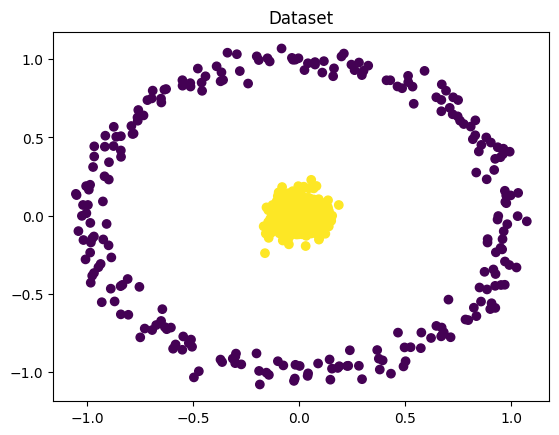

In [27]:
# Generar dataset no lineal
x, y = make_circles(500, factor=0.1, noise=0.05)

# Convertir y en vector columna
y = y.reshape(500, 1)

# Visualización del dataset
plt.scatter(x[:, 0], x[:, 1], c=y)
plt.title("Dataset")
plt.show()

In [28]:
class NeuralNet():

    # Constructor de la red neuronal
    def __init__(self, n_inputs=2, n_hidden=[4, 8, 4], n_outputs=1, activation="relu"):

        # Guardar arquitectura
        self.n_inputs = n_inputs
        self.n_hidden = n_hidden
        self.n_outputs = n_outputs
        self.activation_name = activation

        # Lista con tamaño de cada capa
        layers = [n_inputs] + n_hidden + [n_outputs]
        self.layers = layers

        # Inicialización de pesos, derivadas y bias
        weights = []
        derivatives = []
        bias = []

        for i in range(len(layers) - 1):

            # Pesos inicializados con distribución normal
            w = np.random.normal(scale=0.5, size=(layers[i], layers[i + 1]))

            # Matriz donde se guardará el gradiente
            d = np.zeros((layers[i], layers[i + 1]))

            # Bias inicializados en 0
            b = np.zeros((1, layers[i + 1]))

            weights.append(w)
            derivatives.append(d)
            bias.append(b)

        self.weights = weights
        self.derivatives = derivatives
        self.bias = bias

        # Activaciones de cada capa
        activations = []
        for i in range(len(layers)):
            a = np.zeros((1, layers[i]))
            activations.append(a)

        self.activations = activations

        # Deltas usados para actualizar bias
        deltas = []
        for i in range(len(bias)):
            d = np.zeros((bias[i].shape))
            deltas.append(d)

        self.deltas = deltas


    # Selección de función de activación
    def activation(self, x):
        if self.activation_name == "sigmoid":
            return self.sigmoid(x)
        else:
            return self.relu(x)

    # Selección de derivada de la activación
    def activation_der(self, x):
        if self.activation_name == "sigmoid":
            return self.sigmoid_der(x)
        else:
            return self.relu_der(x)


    # FORWARD PASS
    # Calcula la salida de la red propagando las entradas
    def forward(self, inputs):

        # Primera activación = entrada
        self.activations[0] = inputs

        a = inputs

        # Recorrer todas las capas
        for i in range(len(self.layers) - 1):

            # z = W*x + b
            z = np.dot(a, self.weights[i]) + self.bias[i]

            # Aplicar función de activación
            a = self.activation(z)

            # Guardar activación
            self.activations[i + 1] = a

        return self.activations[-1]


    # BACKPROPAGATION
    # Calcula gradientes usando la regla de la cadena
    def backpropagation(self, error):

        # Recorrer capas en reversa
        back = list(range(len(self.layers) - 1))
        back.reverse()

        for i in back:

            a = self.activations[i + 1]

            # delta = error * derivada activación
            delta = error * self.activation_der(self.activations[i+1])

            self.deltas[i] = delta

            a_current = self.activations[i]

            # Gradiente de los pesos
            d = np.dot(a_current.T, delta)

            self.derivatives[i] = d

            # Error para capa anterior
            error = np.dot(delta, self.weights[i].T)


    # Actualización de pesos mediante gradient descent
    def gradient_descent(self, lr):

        for i in range(len(self.weights)):

            w = self.weights[i]
            d = self.derivatives[i]

            # Actualizar pesos
            w -= lr * d
            self.weights[i] = w

            # Actualizar bias
            self.bias[i] -= lr * np.mean(self.deltas[i], axis=0, keepdims=True)


    # FUNCIONES DE ACTIVACIÓN

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_der(self, x):
        return x * (1 - x)

    def relu(self, x):
        return np.maximum(0, x)

    def relu_der(self, x):
        return (x > 0).astype(float)


    # Función de error MSE
    def mse(self, output, target):
        return np.mean((output - target) ** 2) / 2


    # ENTRENAMIENTO
    def train(self, x, y, lr, err_max):

        err_mse = 1
        errors = []

        # Entrenar hasta alcanzar error deseado
        while err_mse > err_max:

            output = self.forward(x)

            error = output - y

            self.backpropagation(error)

            self.gradient_descent(lr)

            err_mse = self.mse(output, y)

            errors.append(err_mse)

        # Graficar curva de error
        x_axis = range(0, len(errors))
        plt.plot(x_axis, errors)
        plt.title("Error durante entrenamiento")
        plt.show()

Entrenando red con activación SIGMOID


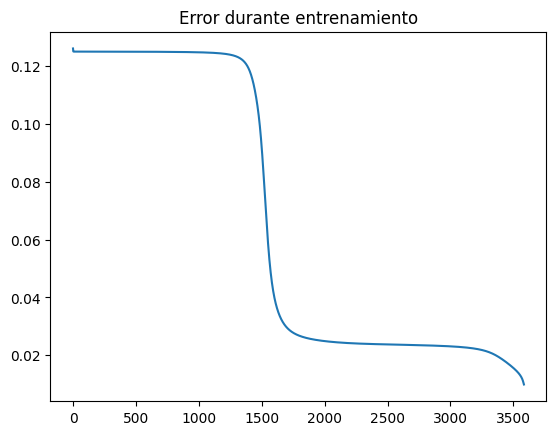

In [29]:
# ---------------------------
# EJEMPLO 1 : SIGMOID
# ---------------------------

print("Entrenando red con activación SIGMOID")

nn_sigmoid = NeuralNet(2, [4, 8, 4], 1, activation="sigmoid")

nn_sigmoid.train(x, y, 0.01, 0.01)

Entrenando red con activación RELU


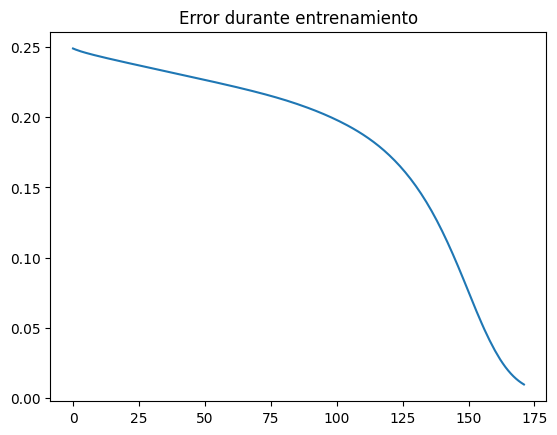

In [30]:
# ---------------------------
# EJEMPLO 2 : RELU
# ---------------------------

print("Entrenando red con activación RELU")

nn_relu = NeuralNet(2, [4, 8, 4], 1, activation="relu")

nn_relu.train(x, y, 0.002, 0.01)

# Readme

Red Neuronal multicapa, que solicita perceptrones de entrada, capas ocultas, perceptrones de salida y función de activación. Se compone de los siguientes pasos.

1.   Red Neuronal (declaración de capas, entradas, pesos, activaciones, deltas)
2.   Funcion de activación
3.   Entrenamiento de red
4.   Error y ajuste

Se usan 2 funciones de activación para el ejercicio, la sigmoide y la relu, este dataset organiza de manera aleatoria dos conjuntos de circulos distribuidos en el plano donde identifica y divide la ubicación de cada set.

# Qué cambió al variar la activación?

En sigmoid tiende a saturarse cuando las entradas son demasiado grandes o pequeñas, tambien hace que el gradiente sea mas pequeño, relu permite que el gradiente fluya mas facilmente en muchas capas.

# Cómo se comportó el loss/métrica

Al usar MSE (mean square error) en el algoritmo se observa que con Sigmoid el error disminuye de manera mas lenta, con esta función para alcanzar el error objetivo debe haber mas iteraciones a diferencia de Relu donde el error suele disminuir mas rapido al inicio y puede haber descensos mas bruscos en la curva de error. Adicional se usa un learning rate menor para Relu ya que puede actualizar los pesos mas agresivamente.

# Principales dificultades o hallazgos.

Se nota la sensibilidad al learning rate comparando el uso de las funciones de activación, si se usa un valor alto con Relu el entrenamiento puede ser inestable y no compila. La función sigmoide se tuvo que correr varias veces ya que en ocasiones gracias a datos aleatorios se queda compilando por que produce gradientes cortos haciendo que  itere mas veces y relentice el entrenamiento. Relu permite convergencia mas rapida y mejor propagación del gradiente en varias capas.